# mRNA / circRNA Codon Optimization

Optimize codon usage for mRNA and circRNA sequences using a language-model-guided beam search with simulated annealing.

- **Optimization Objective**: Minimize MFE (thermodynamic stability) while maintaining CAI (codon adaptation)
- **Method**: Beam search scored by RNA language model log-likelihood, accepted via Metropolis criterion
- **Two Modes**: Full optimization (GPU + model) or plot-only (visualize existing progress files)

In [12]:
# ==================== Configuration ====================
#
# Dependencies:
#   pip install numpy matplotlib linearfold-unofficial
#   For full optimization mode (requires GPU):
#       pip install torch
#       The RNA language model should be loaded from the local model/ directory.
#
# Two modes:
#   1. Plot-only mode: set PROGRESS_FILE to an existing progress file. No GPU needed.
#      PROGRESS_FILE = "progress.txt"
#      FASTA_FILE / UTR5_FILE / UTR3_FILE can be left empty.
#
#   2. Full optimization mode: leave PROGRESS_FILE empty. Requires GPU + 3 input files.
#      FASTA_FILE = "cds.fasta"
#      UTR5_FILE  = "utr5.fasta"
#      UTR3_FILE  = "utr3.fasta"
#
# RNA_TYPE + LINEAGE control the circRNA/mRNA x homo/nolineage combination.
# Leave LINEAGE empty for nolineage mode.

FASTA_FILE = "data/mRNA_circRNA/example_cds.fasta"
UTR5_FILE = "data/mRNA_circRNA/example_utr5.fasta"
UTR3_FILE = "data/mRNA_circRNA/example_utr3.fasta"
ITERATIONS = 400
OUTPUT_DIR = "./data/mRNA_circRNA"
RNA_TYPE = "<rna_circRNA>" # or "<rna_mRNA>"
LINEAGE = ""  # e.g. "d__eukaryota;p__chordata;c__mammalia;o__primates;f__hominidae;g__homo;s__homo_sapiens"
PROGRESS_FILE = "data/mRNA_circRNA/example_progress.txt"  # non-empty = plot-only mode

In [13]:
import sys
import os
import re
import math
import random
import json
import shutil
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

os.environ['OMP_NUM_THREADS'] = '4'

import numpy as np

try:
    import design_paths as DP
except ModuleNotFoundError:
    from notebooks.design import design_paths as DP

def resolve_notebook_path(path_value):
    if not path_value:
        return ''
    return str(DP.resolve_path(path_value))

def resolve_project_path(path_value):
    if not path_value:
        return ''
    path = Path(path_value).expanduser()
    if not path.is_absolute():
        path = DP.project_root() / path_value
    return str(path.resolve())

FASTA_FILE = resolve_notebook_path(FASTA_FILE)
UTR5_FILE = resolve_notebook_path(UTR5_FILE)
UTR3_FILE = resolve_notebook_path(UTR3_FILE)
OUTPUT_DIR = resolve_notebook_path(OUTPUT_DIR)
PROGRESS_FILE = resolve_notebook_path(PROGRESS_FILE)

# ==================== Path Configuration ====================
MODEL_CODE_PATH = resolve_project_path('')
CHECKPOINT_PATH = resolve_project_path('')

## 1. Sequence Utilities

UTR loading, codon table, and translation functions for converting between RNA and protein sequences.

In [14]:
# ==================== UTR Loading ====================

def load_utr_from_fasta(fasta_path):
    """Load UTR sequence (RNA format) from a FASTA file."""
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith('>') or line.startswith('#'):
                continue
            seq = line.strip()
            if seq:
                return seq
    raise ValueError(f"Failed to load UTR sequence from {fasta_path}")

In [15]:
# ==================== Codon Table ====================
CODON_TABLE = {
    'M': ['AUG'], 'F': ['UUU', 'UUC'],
    'L': ['UUA', 'UUG', 'CUU', 'CUC', 'CUA', 'CUG'],
    'I': ['AUU', 'AUC', 'AUA'],
    'V': ['GUU', 'GUC', 'GUA', 'GUG'],
    'S': ['UCU', 'UCC', 'UCA', 'UCG', 'AGU', 'AGC'],
    'P': ['CCU', 'CCC', 'CCA', 'CCG'],
    'T': ['ACU', 'ACC', 'ACA', 'ACG'],
    'A': ['GCU', 'GCC', 'GCA', 'GCG'],
    'Y': ['UAU', 'UAC'],
    'H': ['CAU', 'CAC'],
    'Q': ['CAA', 'CAG'],
    'N': ['AAU', 'AAC'],
    'K': ['AAA', 'AAG'],
    'D': ['GAU', 'GAC'],
    'E': ['GAA', 'GAG'],
    'C': ['UGU', 'UGC'],
    'W': ['UGG'],
    'R': ['CGU', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG'],
    'G': ['GGU', 'GGC', 'GGA', 'GGG'],
    'STOP': ['UAA', 'UAG', 'UGA']
}

REVERSE_CODON_TABLE = {
    codon: aa for aa, codons in CODON_TABLE.items() for codon in codons
}

print(f"Codon table loaded: {len(REVERSE_CODON_TABLE)} codons")

Codon table loaded: 64 codons


In [16]:
# ==================== Translation ====================

def translate_rna_to_protein(rna_seq):
    protein = ""
    for i in range(0, len(rna_seq) - 2, 3):
        codon = rna_seq[i:i+3]
        aa = REVERSE_CODON_TABLE.get(codon, 'X')
        if aa == 'STOP':
            break
        protein += aa
    return protein


def auto_detect_protein_sequence(fasta_path, utr5_len, utr3_len):
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                continue
            seq = line.strip()
            if seq:
                protein = translate_rna_to_protein(seq)
                if len(protein) > 10:
                    return protein
                cds = seq[utr5_len:len(seq)-utr3_len] if len(seq) > utr5_len + utr3_len else seq
                protein = translate_rna_to_protein(cds)
                return protein
    return None

## 2. MFE & CAI Scoring

Compute Minimum Free Energy (LinearFold) and Codon Adaptation Index (human codon usage table) for candidate sequences.

In [17]:
# ==================== MFE + CAI Calculation ====================

def _load_linearfold():
    try:
        import linearfold
        return linearfold
    except ImportError:
        pass
    try:
        import LinearFold
        return LinearFold
    except ImportError:
        raise ImportError("LinearFold not found. Install via: pip install linearfold-unofficial")

def calculate_mfe_worker(rna_seq):
    try:
        LinearFold = _load_linearfold()
        structure, mfe = LinearFold.fold(rna_seq)
        return float(mfe)
    except:
        return 0.0

def batch_calculate_mfe(rna_seqs, max_workers=16):
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        mfes = list(executor.map(calculate_mfe_worker, rna_seqs))
    return mfes

def calculate_cai(seq):
    seq = seq.replace('U', 'T').upper()
    human_codon_usage = {
        'TTT': 17.6, 'TTC': 20.3, 'TTA': 7.7, 'TTG': 12.9, 'CTT': 13.2, 'CTC': 19.6, 'CTA': 7.2, 'CTG': 39.6,
        'ATT': 16.0, 'ATC': 20.8, 'ATA': 7.5, 'ATG': 22.0, 'GTT': 11.0, 'GTC': 14.5, 'GTA': 7.1, 'GTG': 28.1,
        'TCT': 15.2, 'TCC': 17.7, 'TCA': 12.2, 'TCG': 4.4, 'AGT': 12.1, 'AGC': 19.5,
        'CCT': 17.5, 'CCC': 19.8, 'CCA': 16.9, 'CCG': 6.9, 'ACT': 13.1, 'ACC': 18.9, 'ACA': 15.1, 'ACG': 6.1,
        'GCT': 18.4, 'GCC': 27.7, 'GCA': 15.8, 'GCG': 7.4, 'TAT': 12.2, 'TAC': 15.3,
        'CAT': 10.9, 'CAC': 15.1, 'CAA': 12.3, 'CAG': 34.2, 'AAT': 17.0, 'AAC': 19.1,
        'AAA': 24.4, 'AAG': 31.9, 'GAT': 21.8, 'GAC': 25.1, 'GAA': 29.0, 'GAG': 39.6,
        'TGT': 10.6, 'TGC': 12.6, 'TGG': 13.2,
        'CGT': 4.5, 'CGC': 10.4, 'CGA': 6.2, 'CGG': 11.4, 'AGA': 12.2, 'AGG': 12.0,
        'GGT': 10.8, 'GGC': 22.2, 'GGA': 16.5, 'GGG': 16.5,
    }
    codon_to_aa = {
        'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L', 'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
        'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M', 'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
        'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S', 'AGT': 'S', 'AGC': 'S',
        'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P', 'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
        'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A', 'TAT': 'Y', 'TAC': 'Y',
        'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q', 'AAT': 'N', 'AAC': 'N',
        'AAA': 'K', 'AAG': 'K', 'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
        'TGT': 'C', 'TGC': 'C', 'TGG': 'W',
        'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R', 'AGA': 'R', 'AGG': 'R',
        'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G',
    }
    aa_codons = {}
    for codon, aa in codon_to_aa.items():
        if aa not in aa_codons:
            aa_codons[aa] = []
        aa_codons[aa].append(codon)
    weights = {}
    for aa, codons in aa_codons.items():
        max_usage = max(human_codon_usage.get(c, 0.01) for c in codons)
        for codon in codons:
            usage = human_codon_usage.get(codon, 0.01)
            weights[codon] = usage / max_usage
    codons_list = [seq[i:i+3] for i in range(0, len(seq), 3) if len(seq[i:i+3]) == 3]
    log_sum = 0
    count = 0
    for codon in codons_list:
        if codon in weights:
            w = weights[codon]
            if w > 0:
                log_sum += math.log(w)
                count += 1
    if count > 0:
        return math.exp(log_sum / count)
    return 0.0

In [18]:
# ==================== Sequence Processing ====================

def construct_prompt(full_mrna, rna_type='<rna_mRNA>', lineage=''):
    if lineage:
        return f"<bos>|{lineage};{rna_type}|5{full_mrna}"
    else:
        return f"<bos>|{rna_type}|5{full_mrna}"


def load_population_from_fasta(fasta_path, utr5, utr3, target_protein):
    print(f"Loading population from {fasta_path}...")
    sequences = []
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                continue
            seq = line.strip()
            if seq:
                sequences.append(seq)
    if len(sequences) < 8:
        raise ValueError(f"Need at least 8 sequences, got {len(sequences)}")
    sequences = sequences[:8]
    print("  Computing initial MFE...")
    full_seqs = [utr5 + seq + utr3 for seq in sequences]
    mfes = batch_calculate_mfe(full_seqs, max_workers=16)
    population = []
    for seq, mfe in zip(sequences, mfes):
        population.append({"cds": seq, "mfe": mfe})
    print(f"Loaded {len(population)} sequences")
    for i, ind in enumerate(population):
        print(f"  Seq{i+1}: MFE={ind['mfe']:.2f}")
    return population

## 3. Beam Search & Optimization

Language-model-guided beam search over synonymous codons within a sliding window, combined with simulated annealing to balance exploration and exploitation.

In [19]:
# ==================== Beam Search ====================

def parallel_beam_search_multi_victims(model, tokenizer, device, victims_info, beam_width, temperature):
    import torch
    import torch.nn.functional as F

    victim_beams = [{"beams": [("", 0.0)], "info": v} for v in victims_info]
    max_aa_len = max(len(v['target_aa_segment']) for v in victims_info)

    for aa_idx in range(max_aa_len):
        all_expansions = []
        for vid, vb in enumerate(victim_beams):
            info = vb['info']
            target_aa = info['target_aa_segment']
            if aa_idx >= len(target_aa):
                continue
            aa = target_aa[aa_idx]
            valid_codons = CODON_TABLE[aa]
            prefix_text = info['prefix_with_prompt']
            for parent_seq, parent_score in vb['beams']:
                context_text = prefix_text + parent_seq
                for codon in valid_codons:
                    all_expansions.append({
                        'vid': vid, 'parent_seq': parent_seq, 'codon': codon,
                        'parent_score': parent_score, 'context_text': context_text,
                        'full_text': context_text + codon
                    })
        if not all_expansions:
            break

        batch_full_texts = [item["full_text"] for item in all_expansions]
        batch_context_texts = [item["context_text"] for item in all_expansions]
        full_ids_list = [tokenizer.encode(text) for text in batch_full_texts]
        context_ids_list = [tokenizer.encode(text) for text in batch_context_texts]

        max_len = max(len(ids) for ids in full_ids_list)
        input_ids = []
        attention_mask = []
        for ids in full_ids_list:
            padding_length = max_len - len(ids)
            input_ids.append(ids + [0] * padding_length)
            attention_mask.append([1] * len(ids) + [0] * padding_length)

        input_ids = torch.tensor(input_ids, dtype=torch.long, device=device)
        attention_mask = torch.tensor(attention_mask, dtype=torch.long, device=device)
        context_lengths = [len(ids) for ids in context_ids_list]

        with torch.no_grad():
            batch_size = input_ids.shape[0]
            seq_len = input_ids.shape[1]
            position_ids = torch.arange(seq_len, dtype=torch.long, device=device).unsqueeze(0).expand(batch_size, -1)
            sequence_ids = torch.zeros_like(input_ids)
            outputs = model(input_ids=input_ids, position_ids=position_ids, sequence_ids=sequence_ids)
            logits = outputs.logits.clone()
            del outputs
            torch.cuda.empty_cache()

        expansion_scores = {}
        for i, item in enumerate(all_expansions):
            vid = item['vid']
            start_pos = context_lengths[i] - 1
            real_len = attention_mask[i].sum().item()
            if start_pos + 1 >= real_len:
                codon_score = -100.0
            else:
                target_ids = input_ids[i, start_pos+1:real_len]
                target_logits = logits[i, start_pos:real_len-1, :]
                token_log_probs = F.log_softmax(target_logits.float() / temperature, dim=-1)
                selected_log_probs = token_log_probs.gather(1, target_ids.unsqueeze(1)).squeeze(1)
                codon_score = selected_log_probs.sum().item()
            new_seq = item['parent_seq'] + item['codon']
            new_score = item['parent_score'] + codon_score
            if vid not in expansion_scores:
                expansion_scores[vid] = []
            expansion_scores[vid].append((new_seq, new_score))

        del input_ids, attention_mask, logits
        torch.cuda.empty_cache()

        for vid, vb in enumerate(victim_beams):
            if vid in expansion_scores:
                candidates = expansion_scores[vid]
                candidates.sort(key=lambda x: x[1], reverse=True)
                vb['beams'] = candidates[:beam_width]

    results = []
    for vid, vb in enumerate(victim_beams):
        info = vb['info']
        results.append({
            'victim_idx': info['victim_idx'],
            'victim_mfe': info['victim_mfe'],
            'prefix_cds': info['prefix_cds'],
            'suffix_cds': info['suffix_cds'],
            'candidates': [b[0] for b in vb['beams']],
            'window': info['window']
        })
    return results

In [20]:
# ==================== Optimization Loop ====================

def optimization_loop(model, tokenizer, device, population, target_protein, utr5, utr3,
                     rna_type='<rna_mRNA>', lineage='',
                     n_iterations=100, window_size=8, beam_size=10, batch_victims=8, gpu_parallel=2,
                     T_init=2.0, T_min=0.01, cooling_rate=0.995, log_interval=10,
                     output_dir=None, progress_file="optimize_progress.txt"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    T = T_init
    n_codons = len(target_protein)
    progress_f = open(progress_file, 'w', buffering=1)
    accepted_count = 0
    total_attempts = 0

    msg = f"\nStarting optimization from existing population...\n"
    msg += f"  RNA type: {rna_type}\n"
    msg += f"  Lineage: {lineage if lineage else '(none)'}\n"
    msg += f"  Current best MFE: {min(p['mfe'] for p in population):.2f}\n"
    msg += f"  Iterations: {n_iterations}\n"
    msg += f"  Victims per round: {batch_victims}\n"
    msg += f"  Window size: {window_size} codons\n\n"
    print(msg, end='')
    progress_f.write(msg)

    for iteration in range(n_iterations):
        msg = f"\n[Iter {iteration+1:4d}] Processing {batch_victims} victims\n"
        print(msg, end='', flush=True)
        progress_f.write(msg)

        victim_indices = random.sample(range(len(population)), min(batch_victims, len(population)))
        victims_info = []
        for vid, victim_idx in enumerate(victim_indices):
            victim = population[victim_idx]
            victim_cds = victim["cds"]
            start_codon = random.randint(0, n_codons - window_size)
            end_codon = start_codon + window_size
            start_nt = start_codon * 3
            end_nt = end_codon * 3
            prefix_cds = victim_cds[:start_nt]
            suffix_cds = victim_cds[end_nt:]
            full_prefix = utr5 + prefix_cds
            prefix_with_prompt = construct_prompt(full_prefix, rna_type=rna_type, lineage=lineage)
            target_aa_segment = target_protein[start_codon:end_codon]
            victims_info.append({
                'victim_idx': victim_idx, 'victim_mfe': victim['mfe'],
                'prefix_cds': prefix_cds, 'suffix_cds': suffix_cds,
                'prefix_with_prompt': prefix_with_prompt,
                'target_aa_segment': target_aa_segment, 'window': (start_codon, end_codon)
            })

        all_victim_data = []
        n_batches = (len(victims_info) + gpu_parallel - 1) // gpu_parallel
        for batch_idx in range(n_batches):
            start_idx = batch_idx * gpu_parallel
            end_idx = min(start_idx + gpu_parallel, len(victims_info))
            batch_victims_info = victims_info[start_idx:end_idx]
            msg = f"  GPU batch {batch_idx+1}/{n_batches} ({len(batch_victims_info)})... "
            print(msg, end='', flush=True)
            progress_f.write(msg)
            try:
                batch_results = parallel_beam_search_multi_victims(
                    model, tokenizer, device, batch_victims_info, beam_size, T)
                all_victim_data.extend(batch_results)
                msg = "done\n"
            except Exception as e:
                msg = f"FAILED: {e}\n"
            print(msg, end='', flush=True)
            progress_f.write(msg)

        if not all_victim_data:
            continue

        all_full_seqs = []
        candidate_map = []
        for vid, data in enumerate(all_victim_data):
            for cid, cand in enumerate(data['candidates']):
                full_cds = data['prefix_cds'] + cand + data['suffix_cds']
                full_seq = utr5 + full_cds + utr3
                all_full_seqs.append(full_seq)
                candidate_map.append({'vid': vid, 'cid': cid, 'cds': full_cds})

        msg = f"  Parallel MFE ({len(all_full_seqs)} sequences)..."
        print(msg, end='', flush=True)
        progress_f.write(msg)
        all_mfes = batch_calculate_mfe(all_full_seqs, max_workers=64)
        msg = " done\n"
        print(msg, end='', flush=True)
        progress_f.write(msg)

        accepted_this_round = 0
        for vid, data in enumerate(all_victim_data):
            victim_candidate_indices = [i for i, m in enumerate(candidate_map) if m['vid'] == vid]
            victim_mfes = [all_mfes[i] for i in victim_candidate_indices]
            victim_cds_list = [candidate_map[i]['cds'] for i in victim_candidate_indices]
            best_idx = victim_mfes.index(min(victim_mfes))
            new_cds = victim_cds_list[best_idx]
            new_mfe = victim_mfes[best_idx]
            delta_E = new_mfe - data['victim_mfe']
            total_attempts += 1
            if delta_E < 0:
                population[data['victim_idx']] = {"cds": new_cds, "mfe": new_mfe}
                accepted_count += 1
                accepted_this_round += 1
            elif random.random() < math.exp(-delta_E / T):
                population[data['victim_idx']] = {"cds": new_cds, "mfe": new_mfe}
                accepted_count += 1
                accepted_this_round += 1

        msg = f"  Accepted: {accepted_this_round}/{len(all_victim_data)}\n"
        progress_f.write(msg)
        current_best = min(population, key=lambda x: x["mfe"])
        current_best_cai = calculate_cai(current_best['cds'])
        msg = f"  Best MFE: {current_best['mfe']:.2f} kcal/mol | CAI: {current_best_cai:.4f}\n"
        progress_f.write(msg)
        T = max(T * cooling_rate, T_min)

        if (iteration + 1) % log_interval == 0:
            mfes = [ind["mfe"] for ind in population]
            best = min(population, key=lambda x: x["mfe"])
            best_cai = calculate_cai(best['cds'])
            avg_mfe = sum(mfes) / len(mfes)
            accept_rate = accepted_count / total_attempts if total_attempts > 0 else 0
            msg = f"\n{'='*70}\n"
            msg += f"Iter {iteration+1:4d} | MFE={best['mfe']:.2f} | CAI={best_cai:.4f} | Avg={avg_mfe:.2f} | T={T:.4f} | Acc={accept_rate:.1%}\n"
            msg += f"{'='*70}\n\n"
            print(msg, end='', flush=True)
            progress_f.write(msg)
            if (iteration + 1) % 20 == 0:
                iteration_file = output_dir / "continue_iteration.fasta"
                with open(iteration_file, "w") as f:
                    f.write(f"# Iteration: {iteration+1}\n# Best MFE: {best['mfe']:.2f}\n# Best CAI: {best_cai:.4f}\n# Temperature: {T:.4f}\n# Population size: {len(population)}\n#\n")
                    for idx, seq in enumerate(population):
                        f.write(f">seq{idx+1:02d}|mfe={seq['mfe']:.2f}\n{seq['cds']}\n")
                    f.write(f">BEST|mfe={best['mfe']:.2f}|cai={best_cai:.4f}\n{best['cds']}\n")
            accepted_count = 0
            total_attempts = 0

    progress_f.close()
    best = min(population, key=lambda x: x["mfe"])
    return best

## 4. Visualization

Plot the MFE vs CAI optimization trajectory to inspect convergence and the trade-off between thermodynamic stability and codon adaptation.

In [21]:
# ==================== Plotting ====================

def setup_plot_style():
    import matplotlib.pyplot as plt
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
        'font.size': 14, 'axes.titlesize': 18, 'axes.labelsize': 16,
        'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14,
        'axes.linewidth': 2.5, 'lines.linewidth': 2, 'lines.markersize': 6,
        'grid.color': '#D3D3D3', 'grid.linestyle': '-', 'grid.linewidth': 0.8, 'grid.alpha': 0.8
    })

def extract_mfe_cai(filepath, deduplicate=True):
    content = ""
    for enc in ['utf-8', 'gb18030', 'gbk', 'latin-1']:
        try:
            with open(filepath, 'r', encoding=enc) as f:
                content = f.read()
            break
        except (UnicodeDecodeError, FileNotFoundError):
            continue
    if not content:
        try:
            with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()
        except FileNotFoundError:
            print(f"Warning: file not found {filepath}")
            return []
    pattern = r'MFE:\s*([-\d.]+)\s*kcal/mol.*?CAI:\s*([\d.]+)'
    matches = re.findall(pattern, content)
    if not matches:
        print(f"Warning: no data found in {filepath}")
        return []
    if deduplicate:
        prev_mfe, prev_cai = None, None
        results = []
        for i, (mfe, cai) in enumerate(matches, 1):
            if mfe != prev_mfe or cai != prev_cai:
                results.append((i, float(mfe), float(cai)))
                prev_mfe, prev_cai = mfe, cai
        return results
    else:
        return [(i, float(mfe), float(cai)) for i, (mfe, cai) in enumerate(matches, 1)]

def sample_points(points, interval=20):
    if len(points) <= 2:
        return points
    sampled = [points[0]]
    for i in range(interval, len(points) - 1, interval):
        sampled.append(points[i])
    if sampled[-1] != points[-1]:
        sampled.append(points[-1])
    return sampled

def plot_mfe_vs_cai(data_dict, output_file, title='Codon Optimization: MFE vs CAI', sample_interval=20):
    import matplotlib.pyplot as plt
    setup_plot_style()
    default_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    default_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    for idx, (name, points) in enumerate(data_dict.items()):
        if not points:
            continue
        sampled = sample_points(points, sample_interval)
        mfes = np.array([p[1] for p in sampled])
        cais = np.array([p[2] for p in sampled])
        color = default_colors[idx % len(default_colors)]
        marker = default_markers[idx % len(default_markers)]
        ax.plot(cais, mfes, marker=marker, color=color, label=name,
                markerfacecolor=color, markeredgecolor='white', markeredgewidth=0.8,
                linewidth=5, alpha=0.9)
        ax.scatter(cais[0], mfes[0], c='none', marker='o', s=120, zorder=10,
                   edgecolors=color, linewidths=2.5)
        ax.scatter(cais[-1], mfes[-1], c=color, marker='o', s=100, zorder=10,
                   edgecolors='white', linewidths=2)
    ax.set_xlabel('CAI (Codon Adaptation Index)')
    ax.set_ylabel('MFE (kcal/mol)')
    ax.set_title(title, fontsize=18, pad=15)
    ax.legend(loc='upper right', frameon=True, framealpha=1, edgecolor='#CCCCCC')
    ax.grid(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Plot saved to: {output_file}')
    plt.show()
    plt.close()

## 5. Run

Execute in plot-only mode (if `PROGRESS_FILE` is set) or full optimization mode (requires GPU and model checkpoint).

Plot-only mode
Progress file: data/mRNA_circRNA/example_progress.txt
Extracted 170 data points
MFE: -726.00 -> -1069.10
CAI: 0.7503 -> 0.8589
Plot saved to: data/mRNA_circRNA/optimization_mfe_vs_cai.png


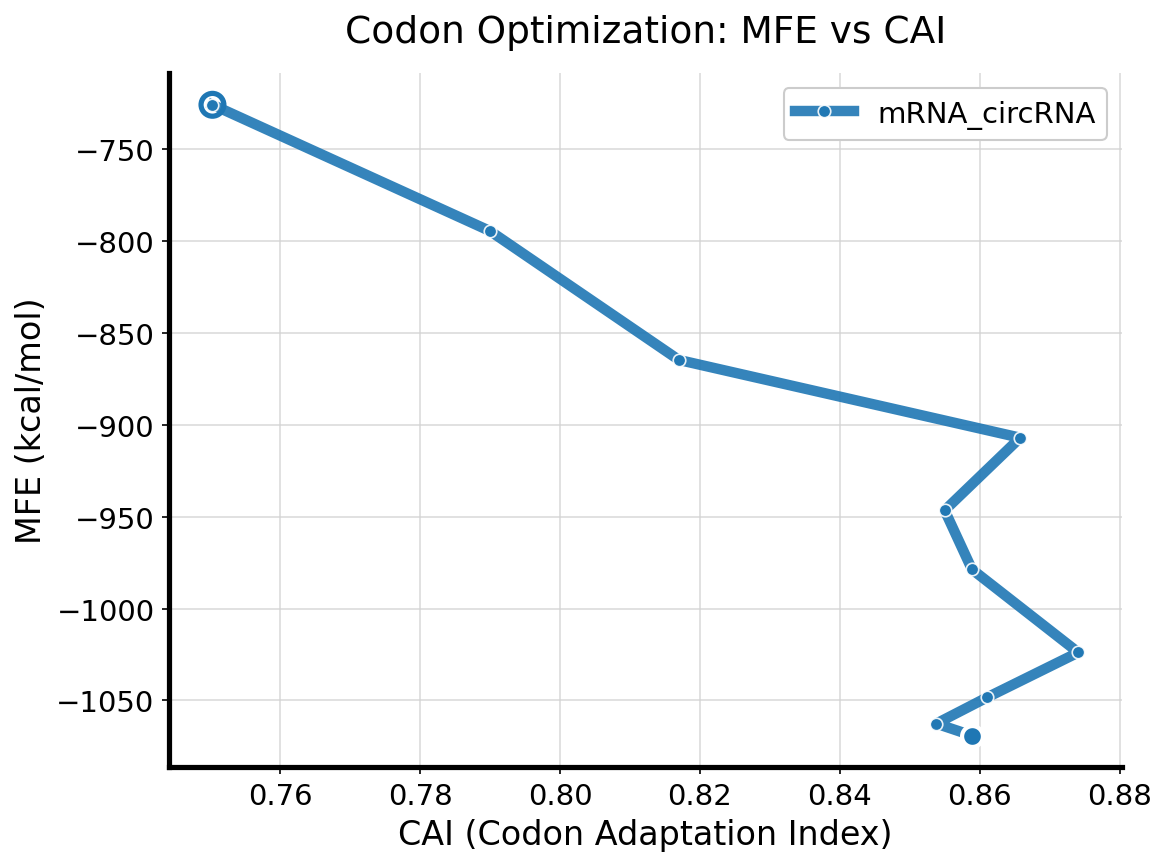

In [22]:
# ==================== Main (Dual Mode) ====================

output_path = Path(OUTPUT_DIR)
output_path.mkdir(parents=True, exist_ok=True)

if PROGRESS_FILE:
    # ===== Plot-only mode =====
    print("="*70)
    print("Plot-only mode")
    print(f"Progress file: {PROGRESS_FILE}")
    print("="*70)
    points = extract_mfe_cai(PROGRESS_FILE, deduplicate=True)
    if points:
        print(f"Extracted {len(points)} data points")
        print(f"MFE: {points[0][1]:.2f} -> {points[-1][1]:.2f}")
        print(f"CAI: {points[0][2]:.4f} -> {points[-1][2]:.4f}")
        label = Path(PROGRESS_FILE).parent.name
        plot_file = output_path / "optimization_mfe_vs_cai.png"
        plot_mfe_vs_cai({label: points}, str(plot_file))
    else:
        print("Error: no data extracted from progress file")
else:
    # ===== Full optimization mode =====
    assert UTR5_FILE and UTR3_FILE, "Full optimization mode requires UTR5_FILE and UTR3_FILE"

    print("="*70)
    print("Codon Optimization")
    print(f"Input: {FASTA_FILE}")
    print(f"RNA type: {RNA_TYPE}")
    print(f"Lineage: {LINEAGE if LINEAGE else '(none)'}")
    print(f"Iterations: {ITERATIONS}")
    print("="*70)

    os.environ['RANK'] = '0'
    os.environ['LOCAL_RANK'] = '0'
    os.environ['WORLD_SIZE'] = '1'
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '29510'
    device = 'cuda:0'

    print("[0] Loading UTRs...")
    utr5 = load_utr_from_fasta(UTR5_FILE)
    utr3 = load_utr_from_fasta(UTR3_FILE)
    print(f"5'UTR: {len(utr5)} nt, 3'UTR: {len(utr3)} nt\n")

    print("[Auto-detect] Protein sequence...")
    target_protein = auto_detect_protein_sequence(FASTA_FILE, len(utr5), len(utr3))
    assert target_protein, "Failed to detect protein sequence from input"
    print(f"Protein length: {len(target_protein)} aa\n")

    print("[1] Loading model...")
    import torch
    sys.path.insert(0, str(Path(MODEL_CODE_PATH).parent))
    from eva.config import EvaConfig
    from eva.causal_lm import EvaForCausalLM
    from eva.lineage_tokenizer import LineageRNATokenizer
    shutil.copy(Path(CHECKPOINT_PATH) / 'tokenizer.json', Path(MODEL_CODE_PATH) / 'tokenizer.json')
    tokenizer = LineageRNATokenizer.from_pretrained(str(CHECKPOINT_PATH))
    with open(Path(CHECKPOINT_PATH) / 'config.json') as f:
        config_dict = json.load(f)
    model_config = EvaConfig(tokenizer=tokenizer, **config_dict)
    model_config.moe_world_size = 1
    weights = torch.load(Path(CHECKPOINT_PATH) / 'model_weights.pt', map_location='cpu', weights_only=False)
    model_config.vocab_size = weights['model.embed_tokens.weight'].shape[0]
    model = EvaForCausalLM(model_config)
    model.load_state_dict(weights)
    model.to(device).bfloat16().eval()
    print("Model loaded\n")

    print("[2] Loading initial population...")
    population = load_population_from_fasta(FASTA_FILE, utr5, utr3, target_protein)

    print("\n[3] Running optimization...")
    progress_file = output_path / "continue_progress.txt"
    best_result = optimization_loop(
        model, tokenizer, device, population, target_protein, utr5, utr3,
        rna_type=RNA_TYPE, lineage=LINEAGE,
        n_iterations=ITERATIONS, window_size=8, beam_size=10, batch_victims=8, gpu_parallel=2,
        T_init=2.0, T_min=0.01, cooling_rate=0.995, log_interval=20,
        output_dir=str(output_path), progress_file=str(progress_file))

    print("\n[4] Saving results...")
    with open(output_path / "optimized_result.fasta", "w") as f:
        f.write(f">optimized|mfe={best_result['mfe']:.2f}\n{best_result['cds']}\n")
    print(f"Saved: {output_path}/optimized_result.fasta\n")

    print("[5] Plotting optimization curve...")
    points = extract_mfe_cai(str(progress_file), deduplicate=True)
    if points:
        plot_file = output_path / "optimization_mfe_vs_cai.png"
        plot_mfe_vs_cai({"Optimization": points}, str(plot_file))

    print("="*70)
    print(f"Done. Final MFE: {best_result['mfe']:.2f} kcal/mol")
    print("="*70)